# Homework I - Programming

Grupo 55  
109247 - Ema Ferrão  
109989 - Pedro Aldeia

Consider the hungarian heart_diseases.csv data available at the homework tab, comprising 9 biological features to classify 284 patients into 2 classes (normal, heart disease).

## Setup and Data Loading

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.patches as mpatches

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("tab10")

In [2]:
# Load data
df = pd.read_csv('hungarian_heart_diseases.csv')

In [3]:
# Check the dataset
print("First 5 rows:")
df.head()

First 5 rows:


,age,sex,chest_pain,trestbps,fasting_blood_sugar,restecg,thalach,exercise_induce_angina,oldpeak,outcome
0,28,1,2,130,0,2,185,0,0.0,0
1,29,1,2,120,0,0,160,0,0.0,0
2,29,1,2,140,0,0,170,0,0.0,0
3,30,0,1,170,0,1,170,0,0.0,0
4,31,0,2,100,0,1,150,0,0.0,0


In [4]:
# Display basic information
print("\n" + "=" * 150)
print("Dataset Overview:")
print("=" * 150)

print(f"Dataset shape: {df.shape}")

feature_names = df.columns[:-1].tolist()
print(f"Features ({len(feature_names)}): {feature_names}")

print(f"\nTarget variable: outcome -> {df['outcome'].unique()}")
print(f"Outcome distribution:")
print(df['outcome'].value_counts())
print(f"Outcome balance:")
print(df['outcome'].value_counts(normalize=True).round(3))

print("\n" + "=" * 150)


Dataset Overview:
Dataset shape: (284, 10)
Features (9): ['age', 'sex', 'chest_pain', 'trestbps', 'fasting_blood_sugar', 'restecg', 'thalach', 'exercise_induce_angina', 'oldpeak']

Target variable: outcome -> [0 1]
Outcome distribution:
outcome
0    181
1    103
Name: count, dtype: int64
Outcome balance:
outcome
0    0.637
1    0.363
Name: proportion, dtype: float64



In [5]:
# Check for missing values
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]

if len(missing_summary) > 0:
    print("Missing Values Summary:")
    print(missing_summary)
else:
    print("No missing values detected in the dataset.")

No missing values detected in the dataset.


In [6]:
# Prepare data for modeling
X = df.drop('outcome', axis=1).values
y = df['outcome'].values

***
## 1. 
Using a stratified 80-20 training-testing split with a fixed seed (random_state=1), assess in a single plot both the training and testing accuracies of a decision tree with minimum sample leaf in {1, 3, 5, 10, 25, 50, 100} and the remaining parameters as default.


In [7]:
# Create 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

print("\n" + "=" * 50)
print("Check set class distribution")
print("=" * 50)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))
print("\n" + "=" * 50)


Check set class distribution
Training set size: 227 samples
Test set size: 57 samples

Training set class distribution:
0    0.639
1    0.361
Name: proportion, dtype: float64

Test set class distribution:
0    0.632
1    0.368
Name: proportion, dtype: float64



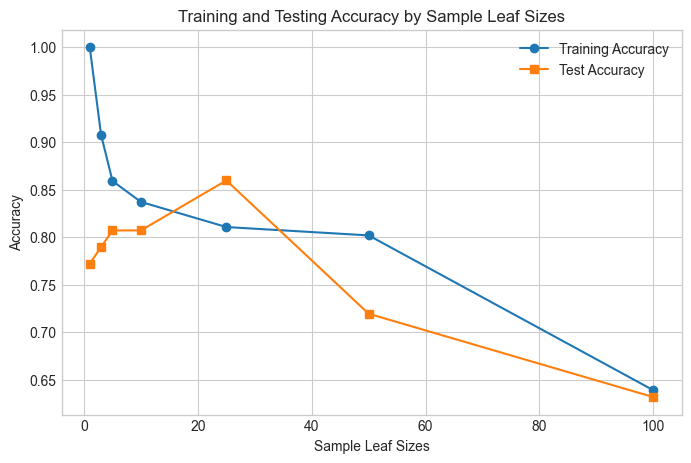

In [8]:
# Values of min_samples_leaf to try
leaf_sizes = [1, 3, 5, 10, 25, 50, 100]

train_accuracies = []
test_accuracies = []

# Train a tree for each leaf size
for leaf in leaf_sizes:
    clf = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=1)
    clf.fit(X_train, y_train)
    
    # Record accuracies
    train_accuracies.append(clf.score(X_train, y_train))
    test_accuracies.append(clf.score(X_test, y_test))

# Plot both curves on the same plot
plt.figure(figsize=(8,5))
plt.plot(leaf_sizes, train_accuracies, marker='o', label="Training Accuracy")
plt.plot(leaf_sizes, test_accuracies, marker='s', label="Test Accuracy")
plt.xlabel("Sample Leaf Sizes")
plt.ylabel("Accuracy")
plt.title("Training and Testing Accuracy by Sample Leaf Sizes")
plt.legend()
plt.grid(True)
plt.show()

***
## 2. 
Critically analyze these results, including the generalization capacity across settings.

The plot shows how training and test accuracy vary with the parameter min_samples_leaf, which controls how many samples are required in each leaf of the decision tree.  
For very small min_samples_leaf (1–5), the decision tree overfits: training accuracy is close to 1.0 while test accuracy remains around 0.77–0.81, showing poor generalization.  
As the leaf size increases to 10–25, training accuracy drops slightly but test accuracy improves, peaking near 0.86 at 25, which reflects a better trade-off between bias and variance and stronger generalization. It is somewhat uncommon for test accuracy to exceed training accuracy, but this can occur due to the randomness of the data split or the relatively small dataset size.  
For very large leaves (50–100), both training and test accuracy decline sharply, down to ~0.64, indicating underfitting: the tree becomes too shallow to capture meaningful patterns.

Overall, generalization capacity is best with moderate regularization (leaf≈25), balancing flexibility and stability.

***
## 3. 
A healthcare provider requested the development of a predictive model achieving at least 80% validation accuracy and 78.5% test accuracy. The dataset must be split into training, validation, and testing sets (60–20–20), using a stratified split. The goal is to identify a model that satisfies the required accuracy within the following hyperparameter ranges: max_depth ∈ [2,4] and min_samples_split ∈ [2,100]. All other hyperparameters should be kept at their default values. Use random_state = 1 to split the data and to create the model.

#### i) Plot the decision tree.

In [9]:
# 1) Peel off the 20% test set
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)

# 2) From the remaining 80%, take 25% as validation (0.25 * 0.80 = 0.20 overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=1, stratify=y_tmp
)

print("\n" + "=" * 50)
print("Check set class distribution")
print("=" * 50)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))
print(f"\nValidation set class distribution:")
print(pd.Series(y_val).value_counts(normalize=True).round(3))
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))

print("\n" + "=" * 50)


Check set class distribution
Training set size: 170 samples
Validation set size: 57 samples
Test set size: 57 samples

Training set class distribution:
0    0.641
1    0.359
Name: proportion, dtype: float64

Validation set class distribution:
0    0.632
1    0.368
Name: proportion, dtype: float64

Test set class distribution:
0    0.632
1    0.368
Name: proportion, dtype: float64



 Best Decision Tree Model 
Max depth         : 2
Min samples split : 2
Validation Acc.   : 84.2%
Test Acc.         : 86.0%



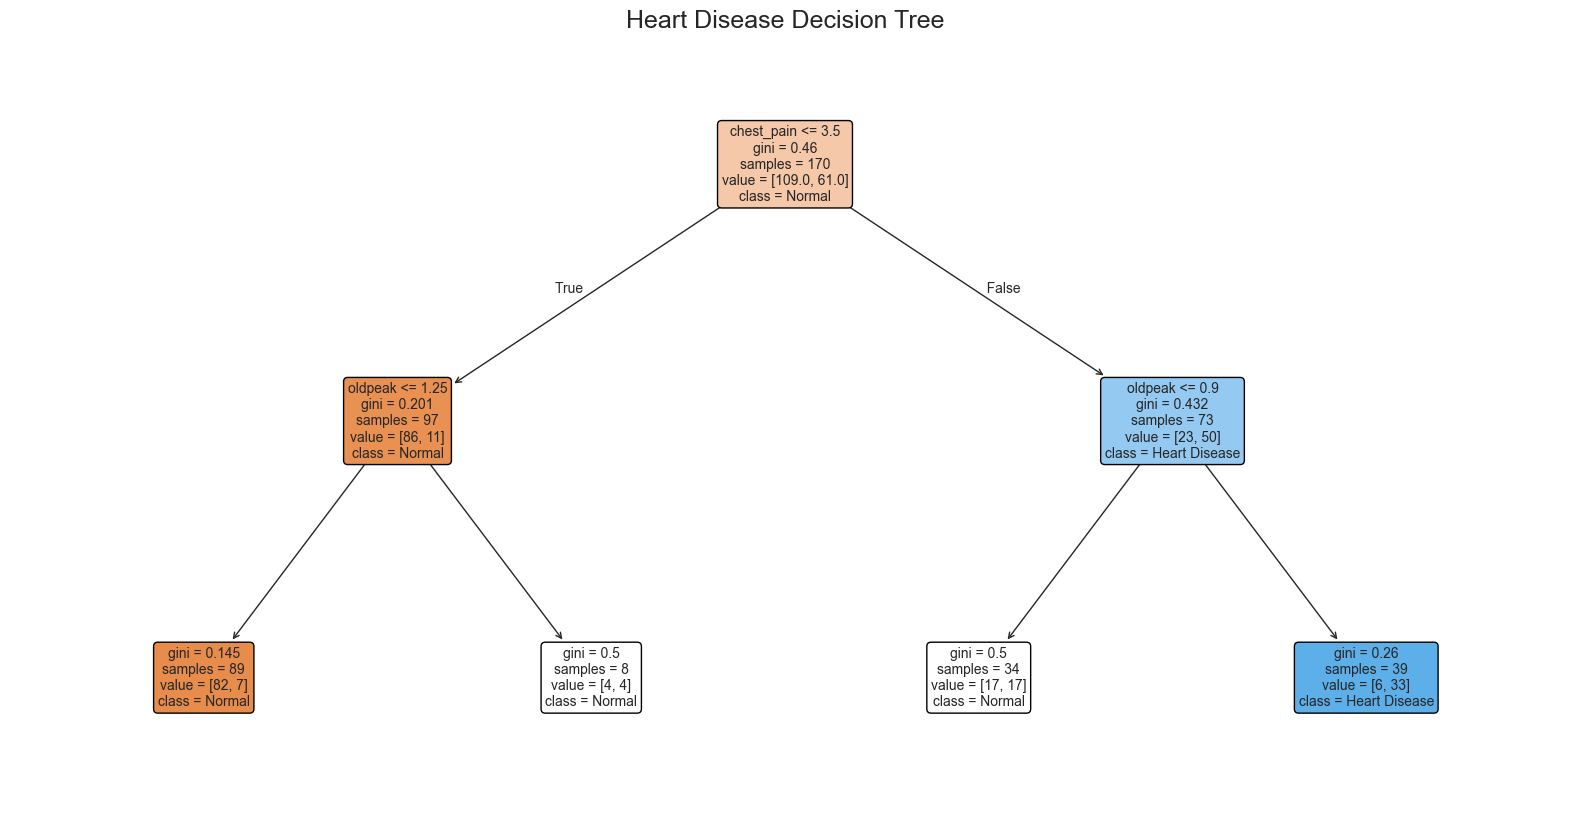

In [10]:
best_model = None
best_val_acc = 0
best_test_acc = 0

# Find the best model
for depth in range(2,5):
    for min_split in range(2,101):
        clf = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_split=min_split,
            random_state=1
        )
        clf.fit(X_train, y_train)

        val_acc = clf.score(X_val, y_val)

        if val_acc >= 0.80:
            test_acc = clf.score(X_test, y_test)
            if test_acc >= 0.785 and (test_acc > best_test_acc):
                best_model = clf
                best_val_acc = val_acc
                best_test_acc = test_acc

# Plot the best model (if found)
if best_model:
    print("="*50)
    print(" Best Decision Tree Model ")
    print("="*50)
    print(f"Max depth         : {best_model.max_depth}")
    print(f"Min samples split : {best_model.min_samples_split}")
    print(f"Validation Acc.   : {best_val_acc*100:.1f}%")
    print(f"Test Acc.         : {best_test_acc*100:.1f}%")
    print("="*50, "\n")

    plt.figure(figsize=(20, 10))
    plot_tree(best_model, 
              feature_names=df.columns[:-1].tolist(), 
              class_names=["Normal", "Heart Disease"],
              fontsize=10,
              filled=True, 
              rounded=True)
    
    plt.title("Heart Disease Decision Tree", fontsize=18)
    plt.show()
else:
    print("No model found that satisfies the accuracy requirements.")


#### ii) Explain what characterizes heart diseases by identifying the conditional associations together with their posterior probabilities.

$P(\text{Heart Disease} \mid \text{chest pain} > 3.5) = \tfrac{50}{73} \approx 68\%$

$P(\text{Heart Disease} \mid \text{chest pain} > 3.5 \;\wedge\; \text{oldpeak} > 0.9) = \tfrac{33}{39} \approx 85\%$

$P(\text{Normal} \mid \text{chest pain} \leq 3.5) = \tfrac{86}{97} \approx 89\%$

$P(\text{Normal} \mid \text{chest pain} \leq 3.5 \;\wedge\; \text{oldpeak} \leq 1.25) = \tfrac{82}{89} \approx 92\%$

<br>
The decision tree highlights chest pain as the key feature for predicting heart disease. Patients with chest pain > 3.5 have a 68% probability of heart disease, which rises to about 85% when combined with oldpeak > 0.9. In contrast, patients with chest pain ≤ 3.5 are mostly normal, with an 89% probability of not having heart disease, and adding the oldpeak condition only slightly increases this figure to 92% (oldpeak ≤ 1.25).

Overall, patients with high chest pain, especially when paired with high oldpeak, have the greatest risk of heart disease. When chest pain is low, patients are predominantly normal, and oldpeak has little additional influence. Thus, chest pain emerges as the main discriminative feature, with oldpeak playing a secondary role, while the remaining features offer no relevant predictive value in this model.